In [1]:
import os
from glob import glob
import numpy as np
import random
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

  2%|▏         | 24/1517 [00:00<00:44, 33.67it/s]


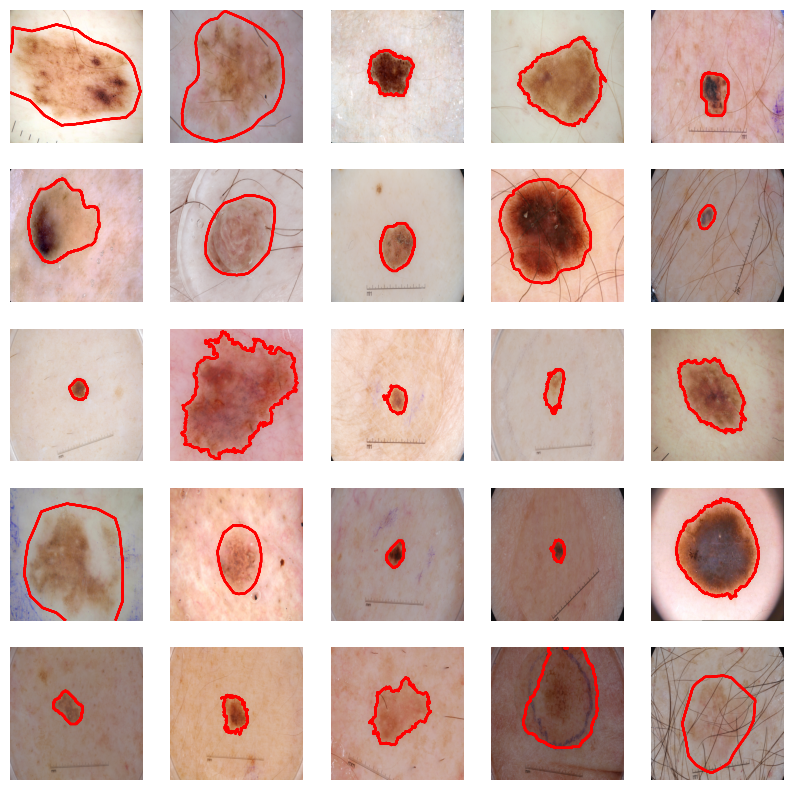

In [51]:
data_dir = "data/nnUNet_raw"
dataset = "Dataset300_isic2018"
dst_dir = "debug/eda"
os.makedirs(dst_dir, exist_ok=True)

imgs = glob(os.path.join(data_dir, dataset, "imagesTr", "*.png"))
random.shuffle(imgs)

num_samples = 25
num_cols = 5
num_rows = num_samples // num_cols
plt.figure(figsize=(10, 10))
for i, img_path in enumerate(tqdm(imgs)):
    label_path = img_path.replace("imagesTr", "labelsTr").replace("_0000.png", ".png")
    img = np.array(Image.open(img_path))
    label = np.array(Image.open(label_path))

    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(img)
    plt.contour(label, colors="red")
    plt.axis("off")
    if i == num_samples - 1:
        break
plt.savefig(os.path.join(dst_dir, "images.svg"), format="svg", bbox_inches="tight")
plt.show()